<a href="https://colab.research.google.com/github/nguoitinhmuadong-1/BT/blob/master/BT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.1 MB/s eta 0:00:00


Câu 1

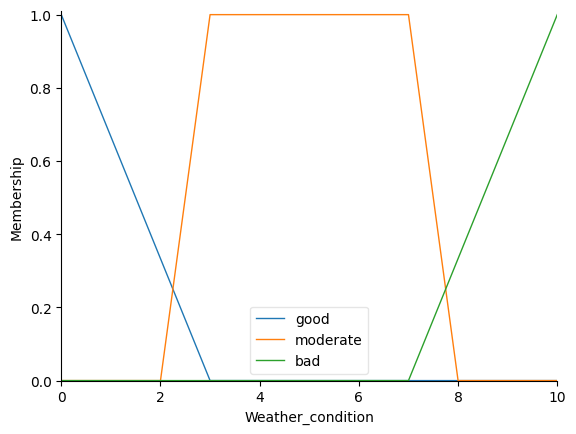

In [2]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
# tạo hàm
Ride_distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'Ride_distance')
Traffic_condition = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Traffic_condition')
Demand = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Demand')
Weather_condition = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'Weather_condition')
Customer_rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'Customer_rating')
Ride_punctuality = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Ride_punctuality')
Cost = ctrl.Consequent(np.arange(10,350.1, 0.1), 'Cost')
Reward = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'Reward')
# hàm liên thuộc
Ride_distance['short'] = fuzz.trimf(Ride_distance.universe, [0, 0, 3])
Ride_distance['medium'] = fuzz.trimf(Ride_distance.universe, [2, 5, 8])
Ride_distance['long'] = fuzz.trimf(Ride_distance.universe, [6, 20, 20])
Ride_distance['very long'] = fuzz.trimf(Ride_distance.universe, [18, 50, 50])
Traffic_condition['low'] = fuzz.trimf(Traffic_condition.universe, [0, 0, 0.3])
Traffic_condition['medium'] = fuzz.trimf(Traffic_condition.universe, [0.2, 0.45, 0.7])
Traffic_condition['high'] = fuzz.trimf(Traffic_condition.universe, [0.6, 1, 1])
Demand['low'] = fuzz.trimf(Demand.universe, [0, 0, 0.3])
Demand['medium'] = fuzz.trimf(Demand.universe, [0.2, 0.45, 0.7])
Demand['high'] = fuzz.trimf(Demand.universe, [0.6, 1, 1])
Weather_condition['good'] = fuzz.trimf(Weather_condition.universe, [0, 0, 3])
Weather_condition['moderate'] = fuzz.trapmf(Weather_condition.universe, [2,3, 7, 8])
Weather_condition['bad'] = fuzz.trimf(Weather_condition.universe, [7, 10, 10])
Customer_rating['poor'] = fuzz.trimf(Customer_rating.universe, [1, 1, 2.5])
Customer_rating['average'] = fuzz.trimf(Customer_rating.universe, [2,3,4])
Customer_rating['good'] = fuzz.trimf(Customer_rating.universe, [3.5, 5, 5])
Ride_punctuality['late'] = fuzz.trimf(Ride_punctuality.universe, [0, 0, 0.5])
Ride_punctuality['on time'] = fuzz.trimf(Ride_punctuality.universe, [0.4, 0.6, 0.8])
Ride_punctuality['early'] = fuzz.trimf(Ride_punctuality.universe, [0.7, 1, 1])
Cost['low'] = fuzz.trimf(Cost.universe, [10, 10, 80])
Cost['medium'] = fuzz.trimf(Cost.universe, [75,110,145])
Cost['high'] = fuzz.trimf(Cost.universe, [140, 180, 205])
Cost['very high'] = fuzz.trimf(Cost.universe, [190, 350, 350])
Reward['none'] = fuzz.trimf(Reward.universe, [0, 0, 30])
Reward['few'] = fuzz.trimf(Reward.universe, [25, 35, 50])
Reward['moderate'] = fuzz.trimf(Reward.universe, [45, 60, 80])
Reward['high'] = fuzz.trimf(Reward.universe, [75, 100, 100])
Weather_condition.view()

In [3]:
# Cost rules
rule1 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['low'] & Demand['low'], Cost['low'])
rule2 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['medium'] & Demand['high'], Cost['medium'])
rule3 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['high'] & Demand['high'], Cost['high'])
rule4 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['medium'] & Weather_condition['good'], Cost['medium'])
rule5 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Weather_condition['bad'], Cost['very high'])
rule6 = ctrl.Rule(Ride_distance['very long'] & Traffic_condition['high'] & Demand['high'], Cost['very high'])
rule7 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['low'] & Demand['low'], Cost['medium'])
rule8 = ctrl.Rule(Ride_distance['short'] & Traffic_condition['high'] & Weather_condition['bad'], Cost['high'])
rule9 = ctrl.Rule(Ride_distance['very long'] & Weather_condition['bad'], Cost['very high'])
rule10 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Weather_condition['moderate'], Cost['medium'])

In [4]:
# Reward rules
rule11 = ctrl.Rule(Customer_rating['good'] & Ride_punctuality['early'], Reward['high'])
rule12 = ctrl.Rule(Customer_rating['average'] & Ride_punctuality['on time'], Reward['moderate'])
rule13 = ctrl.Rule(Customer_rating['poor'] & Ride_punctuality['late'], Reward['none'])
rule14 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Ride_punctuality['on time'], Reward['high'])
rule15 = ctrl.Rule(Ride_distance['medium'] & Traffic_condition['medium'] & Customer_rating['good'], Reward['moderate'])
rule16 = ctrl.Rule(Customer_rating['poor'] & Ride_punctuality['late'], Reward['none'])
rule17 = ctrl.Rule(Ride_distance['long'] & Weather_condition['moderate'] & Customer_rating['good'], Reward['high'])
rule18 = ctrl.Rule(Ride_distance['short']  & Customer_rating['average'] & Ride_punctuality['on time'], Reward['few'])
rule19 = ctrl.Rule(Ride_distance['long'] & Traffic_condition['high'] & Ride_punctuality['late'], Reward['few'])
rule20 = ctrl.Rule(Ride_distance['medium'] & Weather_condition['moderate'] & Customer_rating['average'], Reward['moderate'])

110.00000000000024
61.66666666666672


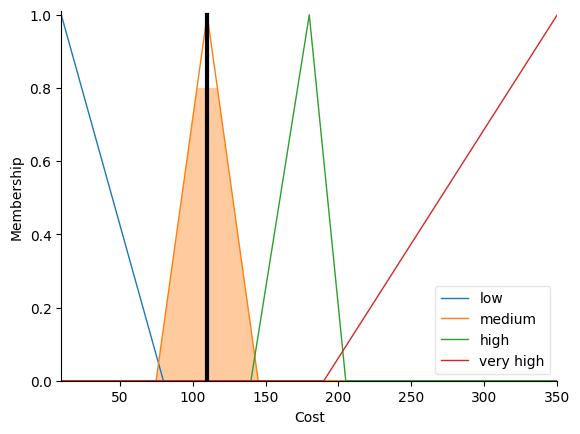

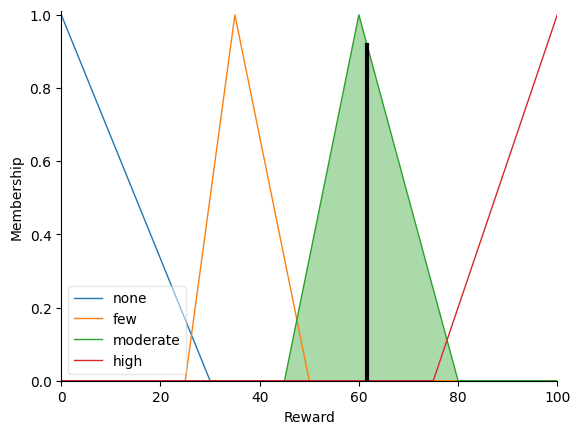

In [5]:
import matplotlib.pyplot as plt

Cost_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10])
Reward_ctrl = ctrl.ControlSystem([rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])
cost = ctrl.ControlSystemSimulation(Cost_ctrl)
reward = ctrl.ControlSystemSimulation(Reward_ctrl)
cost.input['Ride_distance'] = 5
cost.input['Traffic_condition'] = 0.45
cost.input['Demand'] = 0.6
cost.input['Weather_condition'] = 6
cost.compute()
reward.input['Ride_distance'] = 5
reward.input['Customer_rating'] = 3
reward.input['Ride_punctuality'] = 0.6
reward.input['Weather_condition'] = 6
reward.compute()
print(cost.output['Cost'])
print(reward.output['Reward'])
Cost.view(sim=cost)
Reward.view(sim=reward)
plt.show()


Câu 2

In [6]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
# tạo hàm
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store Rating')
volume = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Sales Volume')
profit = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Profit Margin')
event = ctrl.Antecedent(np.arange(1, 90.1, 0.1), 'Seasonal Event')
discounts = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Competitor Discounts')
chietkhau = ctrl.Consequent(np.arange(0, 0.71, 0.1), 'Tỷ lệ phần trăm chiết khấu')

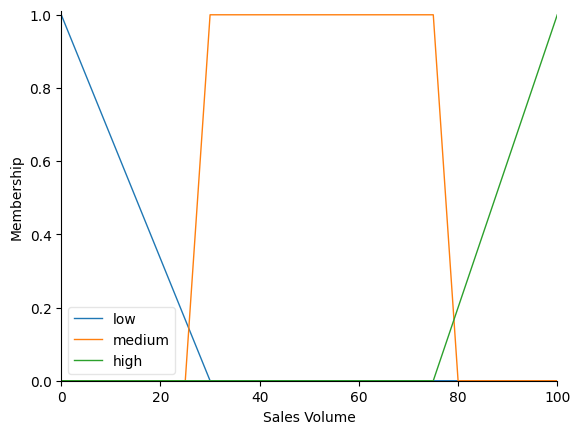

In [8]:
# hàm liên thuộc
rating['low'] = fuzz.trimf(rating.universe, [0, 0, 4])
rating['medium'] = fuzz.trimf(rating.universe, [4,4.25,4.5])
rating['high'] = fuzz.trimf(rating.universe, [4.5, 5, 5])
volume['low'] = fuzz.trimf(volume.universe, [0, 0, 30])
volume['medium'] = fuzz.trapmf(volume.universe, [25,30,75,80])
volume['high'] = fuzz.trimf(volume.universe, [75, 100, 100])
profit['low'] = fuzz.trimf(profit.universe, [0, 0, 0.3])
profit['medium'] = fuzz.trimf(profit.universe, [0.25, 0.5,0.8])
profit['high'] = fuzz.trimf(profit.universe, [0.75, 1, 1])
event['none'] = fuzz.trimf(event.universe, [0, 0, 30])
event['moderate'] = fuzz.trimf(event.universe, [20,45,70])
event['high'] = fuzz.trimf(event.universe, [60,90,90])
discounts['low'] = fuzz.trimf(discounts.universe, [0, 0, 0.3])
discounts['medium'] = fuzz.trimf(discounts.universe, [0.2,0.5,0.8])
discounts['high'] = fuzz.trimf(discounts.universe, [0.7, 1,1])
chietkhau['very low'] = fuzz.trimf(chietkhau.universe, [0, 0, 0.05])
chietkhau['low'] = fuzz.trimf(chietkhau.universe, [0.05,0.075,0.1])
chietkhau['medium'] = fuzz.trimf(chietkhau.universe, [0.1,0.15,0.2])
chietkhau['high'] = fuzz.trimf(chietkhau.universe, [0.2,0.3,0.4])
chietkhau['very high'] = fuzz.trimf(chietkhau.universe, [0.4,0.7,0.7])
volume.view()

In [9]:
# Rules
rule1 = ctrl.Rule(rating['high'] & volume['high'] & profit['high'], chietkhau['very low'])
rule2 = ctrl.Rule(rating['low'] & volume['low'] & profit['high'], chietkhau['high'])
rule3 = ctrl.Rule(event['high'] & discounts['high'] , chietkhau['very high'])
rule4 = ctrl.Rule(rating['medium'] & volume['medium'] & profit['medium'], chietkhau['medium'])
rule5 = ctrl.Rule(discounts['low'] & volume['high'] & profit['low'], chietkhau['very low'])
rule6 = ctrl.Rule(rating['low'] & event['none'], chietkhau['medium'])
rule7 = ctrl.Rule(volume['low'] & profit['low'], chietkhau['very high'])

0.555952380952381


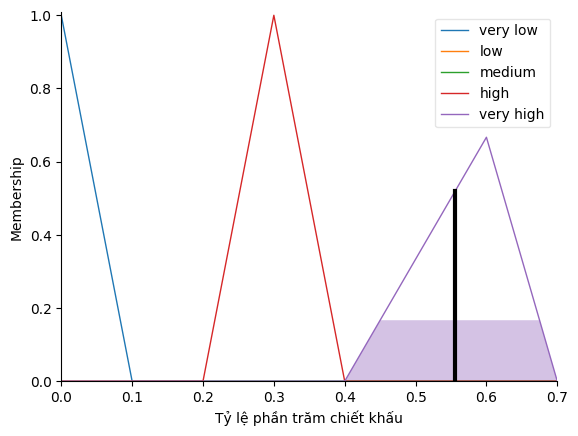

In [10]:
chietkhau_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
chietkhaufn = ctrl.ControlSystemSimulation(chietkhau_ctrl)
chietkhaufn.input['Store Rating'] = 4.3
chietkhaufn.input['Sales Volume'] = 45
chietkhaufn.input['Profit Margin'] = 0.2
chietkhaufn.input['Seasonal Event'] = 80
chietkhaufn.input['Competitor Discounts'] = 0.75
chietkhaufn.compute()
print(chietkhaufn.output['Tỷ lệ phần trăm chiết khấu'])
chietkhau.view(sim=chietkhaufn)

Câu 3

In [11]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
# tạo hàm
demand = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Product Demand')
pressure = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Competitor Pricing Pressure')
reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Store Reputation')
profit = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Profit Margin')
seasond = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Seasonal Demand')
discount = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'Discount Percentage')

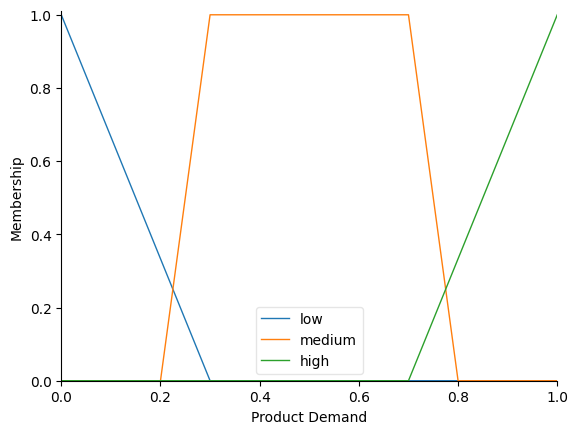

In [12]:
# hàm liên thuộc
demand['low'] = fuzz.trimf(demand.universe, [0, 0, 0.3])
demand['medium'] = fuzz.trapmf(demand.universe, [0.2, 0.3,0.7,0.8])
demand['high'] = fuzz.trimf(demand.universe, [0.7, 1,1])
pressure['low'] = fuzz.trimf(pressure.universe, [0, 0, 0.3])
pressure['medium'] = fuzz.trimf(pressure.universe, [0.2, 0.5,0.8])
pressure['high'] = fuzz.trimf(pressure.universe, [0.7, 1,1])
reputation['low'] = fuzz.trimf(reputation.universe, [0, 0,4])
reputation['medium'] = fuzz.trimf(reputation.universe, [4,4.25,4.5])
reputation['high'] = fuzz.trimf(reputation.universe, [4.5,5,5])
profit['low'] = fuzz.trimf(profit.universe, [0, 0, 0.3])
profit['medium'] = fuzz.trimf(profit.universe, [0.2,0.5,0.8])
profit['high'] = fuzz.trimf(profit.universe, [0.7,1,1])
seasond['none'] = fuzz.trimf(seasond.universe, [0, 0, 0.4])
seasond['medium'] = fuzz.trimf(seasond.universe, [0.2,0.5,0.8])
seasond['high'] = fuzz.trimf(seasond.universe, [0.6, 1,1])
discount['very low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5,7.5,10])
discount['medium'] = fuzz.trimf(discount.universe, [10,15,20])
discount['high'] = fuzz.trimf(discount.universe, [20,30,40])
discount['very high'] = fuzz.trimf(discount.universe, [40,70,70])
demand.view()

In [27]:
#rules
rule1 = ctrl.Rule(demand['high'] & pressure['low'] & profit['low'], discount['very low'])
rule2 = ctrl.Rule(demand['low'] & pressure['high'] & profit['high'], discount['high'])
rule3 = ctrl.Rule(seasond['high'] & reputation['high'] & profit['medium'], discount['medium'])
rule4 = ctrl.Rule(seasond['high'] & pressure['high'] & profit['high'], discount['very high'])
rule5 = ctrl.Rule(demand['medium'] & reputation['low'] & profit['low'], discount['medium'])
rule6 = ctrl.Rule(demand['high'] & seasond['none']& pressure['low'], discount['very low'])
rule7 = ctrl.Rule(seasond['medium'] & pressure['medium'] & profit['high'], discount['medium'])

15.00000000000001


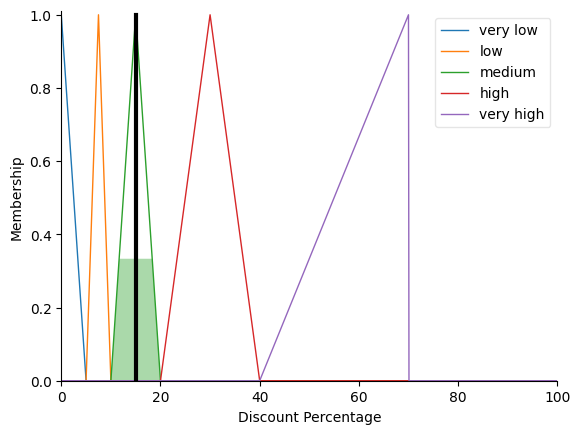

In [51]:
discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discountfn = ctrl.ControlSystemSimulation(discount_ctrl)
discountfn.input['Product Demand'] = 0.75
discountfn.input['Competitor Pricing Pressure'] = 0.54
discountfn.input['Store Reputation'] = 4.2
discountfn.input['Profit Margin'] = 0.9
discountfn.input['Seasonal Demand'] = 0.7
discountfn.compute()
print(discountfn.output['Discount Percentage'])
discount.view(sim=discountfn)

Câu 4

In [58]:
# tạo hàm
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
density = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Order Density')
urgency = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Delivery Urgency')
load = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'Current Load')
traffic = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Traffic Conditions')
profit = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Profit Per Delivery')
combine = ctrl.Consequent(np.arange(0,100.1,0.1), 'Number of Orders to Combine')
priority = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'Delivery Priority')

In [61]:
# hàm liên thuộc
density['low'] = fuzz.trimf(density.universe, [0, 0, 0.3])
density['medium'] = fuzz.trapmf(density.universe, [0.2, 0.3, 0.7,0.8])
density['high'] = fuzz.trimf(density.universe, [0.7, 1, 1])
urgency['low'] = fuzz.trimf(urgency.universe, [0, 0, 0.4])
urgency['medium'] = fuzz.trimf(urgency.universe, [0.3, 0.5,0.7])
urgency['high'] = fuzz.trimf(urgency.universe, [0.6, 1, 1])
load['low'] = fuzz.trimf(load.universe, [0, 0, 30])
load['medium'] = fuzz.trimf(load.universe, [20, 45, 70])
load['high'] = fuzz.trimf(load.universe, [60, 100,100])
traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 0.3])
traffic['medium'] = fuzz.trimf(traffic.universe, [0.2, 0.4, 0.6])
traffic['high'] = fuzz.trimf(traffic.universe, [0.5, 1, 1])
profit['low'] = fuzz.trimf(profit.universe, [0, 0, 0.4])
profit['medium'] = fuzz.trimf(profit.universe, [0.3, 0.5, 0.7])
profit['high'] = fuzz.trimf(profit.universe, [0.6, 1, 1])
combine['low'] = fuzz.trimf(combine.universe, [0, 0, 30])
combine['medium'] = fuzz.trimf(combine.universe, [20, 50, 80])
combine['high'] = fuzz.trimf(combine.universe, [70, 100, 100])
priority['low'] = fuzz.trimf(priority.universe, [0, 0, 0.4])
priority['medium'] = fuzz.trimf(priority.universe, [0.3, 0.5, 0.7])
priority['high'] = fuzz.trimf(priority.universe, [0.6, 1, 1])

In [74]:
# Combine Rules
rule1 = ctrl.Rule(density['high']  & load['low'] & traffic['low'] , combine['high'])
rule2 = ctrl.Rule(density['medium'] & urgency['medium'] & traffic['high'], combine['medium'])
rule3 = ctrl.Rule(density['high'] & load['high'] & profit['medium'], combine['medium'])
rule4 = ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine['medium'])
rule5 = ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine['medium'])
# Priority Rules
rule6 = ctrl.Rule(urgency['high'] & profit['high'], priority['high'])
rule7 = ctrl.Rule(urgency['medium']& traffic['medium'], priority['medium'])
rule8 = ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low'])


86.21212121212123
0.5


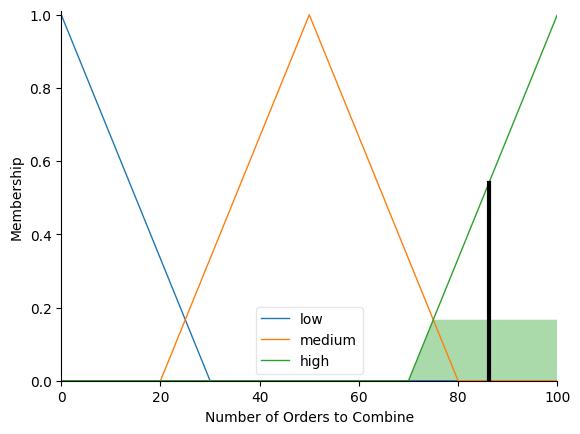

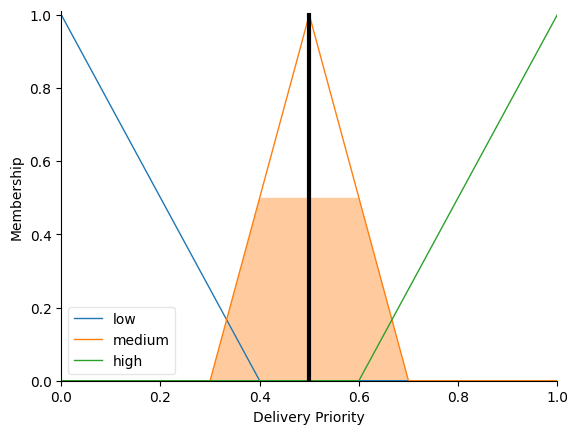

In [84]:
combine_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
priority_ctrl = ctrl.ControlSystem([rule6, rule7, rule8])
combinefn = ctrl.ControlSystemSimulation(combine_ctrl)
priorityfn = ctrl.ControlSystemSimulation(priority_ctrl)
combinefn.input['Order Density'] = 0.85
combinefn.input['Delivery Urgency'] = 0.4
combinefn.input['Current Load'] = 15
combinefn.input['Traffic Conditions'] = 0.25
combinefn.input['Profit Per Delivery'] = 0.5
combinefn.compute()
priorityfn.input['Order Density'] = 0.85
priorityfn.input['Delivery Urgency'] = 0.4
priorityfn.input['Profit Per Delivery'] = 0.25
priorityfn.input['Traffic Conditions'] = 0.5
priorityfn.compute()
print(combinefn.output['Number of Orders to Combine'])
print(priorityfn.output['Delivery Priority'])
combine.view(sim=combinefn)
priority.view(sim=priorityfn)